# Lab 10: Histogram of Oriented Gradients (HOG)
**Họ và tên:** Bùi Quang Chiến  
**MSSV:** 23001837  

## 8.4. Bài tập nâng cao
1. So sánh HOG visualization của ảnh gốc và ảnh blur.
2. So sánh ảnh gốc và ảnh quay 15°, 30°; nhận xét tính nhạy quay của HOG.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure
from skimage import data
from scipy.ndimage import rotate

# Thiết lập font chữ cho plot
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 14

### Hàm hỗ trợ trích xuất và hiển thị HOG
Chúng ta viết một hàm tiện ích để tính toán HOG và trực quan hóa (visualization) để tái sử dụng.

In [2]:
def extract_and_visualize_hog(img, title="HOG Visualization"):
    """
    Hàm hỗ trợ trích xuất đặc trưng HOG và lấy ảnh visualization.
    """
    # Tính HOG
    fd, hog_image = hog(img, orientations=9, pixels_per_cell=(8, 8),
                        cells_per_block=(2, 2), visualize=True, block_norm='L2-Hys')
    
    # Chuẩn hóa cường độ ảnh hiển thị HOG để dễ nhìn hơn
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
    
    # Hiển thị
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
    ax1.imshow(img, cmap=plt.cm.gray)
    ax1.set_title(f'{title} - Gốc')
    ax1.axis('off')
    
    ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
    ax2.set_title(f'{title} - HOG')
    ax2.axis('off')
    plt.tight_layout()
    plt.show()
    
    return fd, hog_image_rescaled

### Chuẩn bị dữ liệu mẫu
Sử dụng một ảnh có sẵn từ thư viện skimage (ảnh camera) làm mẫu chuẩn để test.

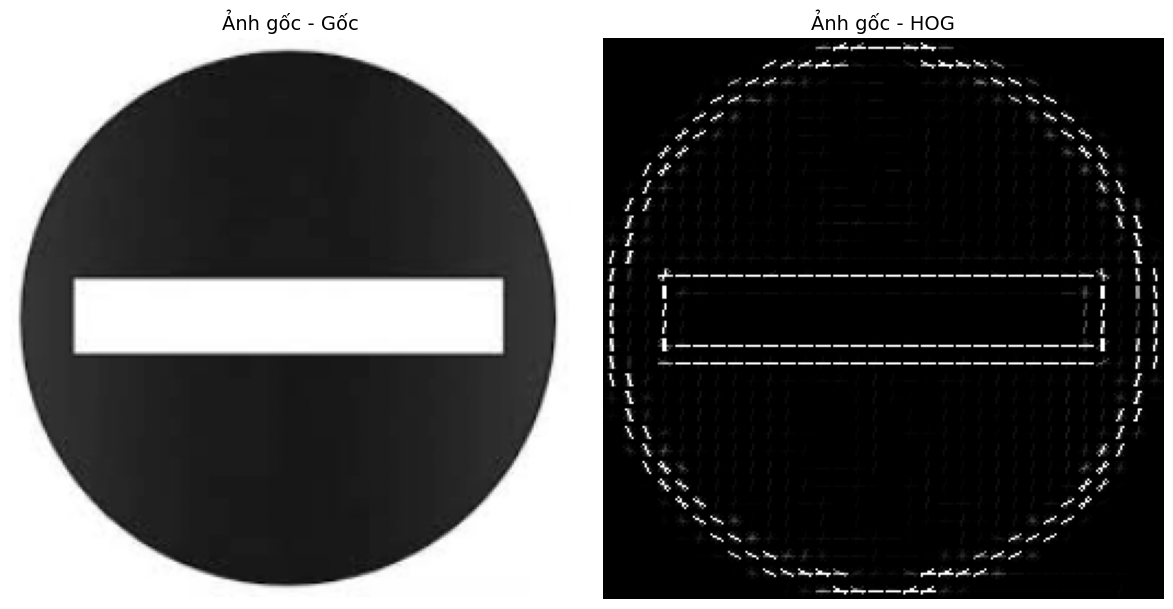

In [3]:
# Tải ảnh biển báo cấm đi ngược chiều, resize để HOG chạy nhanh và hình rõ cell
imgPath = "data/cam-di-nguoc-chieu.jpeg"
img_original = cv2.imread(imgPath, cv2.IMREAD_GRAYSCALE)
img_original = cv2.resize(img_original, (256, 256))

# Trực quan hóa ảnh gốc
_ = extract_and_visualize_hog(img_original, "Ảnh gốc")

### 1. So sánh HOG visualization của ảnh gốc và ảnh blur
Chúng ta sẽ làm mờ ảnh (blur) bằng bộ lọc Gaussian và xem HOG thay đổi như thế nào.

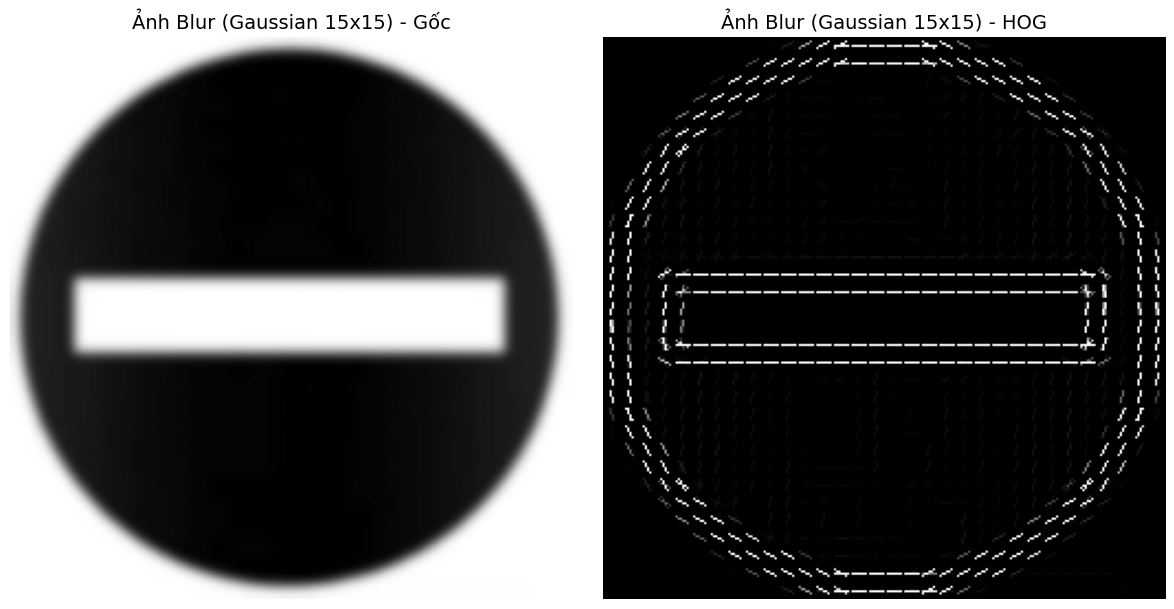

In [4]:
# Làm mờ ảnh bằng Gaussian Blur
img_blur = cv2.GaussianBlur(img_original, (15, 15), 0)

# Trực quan hóa ảnh bị làm mờ
_ = extract_and_visualize_hog(img_blur, "Ảnh Blur (Gaussian 15x15)")

**Nhận xét (Gốc vs Blur):** 
- Ở **ảnh gốc**, các đường nét cạnh của biển báo (vành tròn lõi, thanh ngang ngang màu trắng trên nền đỏ) rất sắc nét, dẫn đến gradient có magnitude lớn. Visualiztion HOG cho thấy các phân bố hướng (orientation) rất mạnh, biểu diễn rõ đường viền cấu trúc tròn của biển báo và thanh ngang phía trong.
- Ở **ảnh blur**, việc làm mờ đã làm giảm độ chênh lệch mức xám cục bộ (làm mượt gradient). Magnitude của gradient yếu đi đáng kể, và nhiều chi tiết cạnh nhỏ bị biến mất. Vì vậy, đặc trưng HOG mất đi sự sắc bén ở những vùng chi tiết, sự xuất hiện các nét vẽ hướng cũng mờ đi, ảnh HOG visualization thể hiện các đặc trưng phân bố tỏa đều đặn nhưng kém nổi bật hơn.

### 2. So sánh ảnh gốc và ảnh quay 15°, 30°; nhận xét tính nhạy quay của HOG
Chúng ta sẽ thực hiện phép quay ảnh (rotate) các góc 15° và 30° và quan sát HOG.

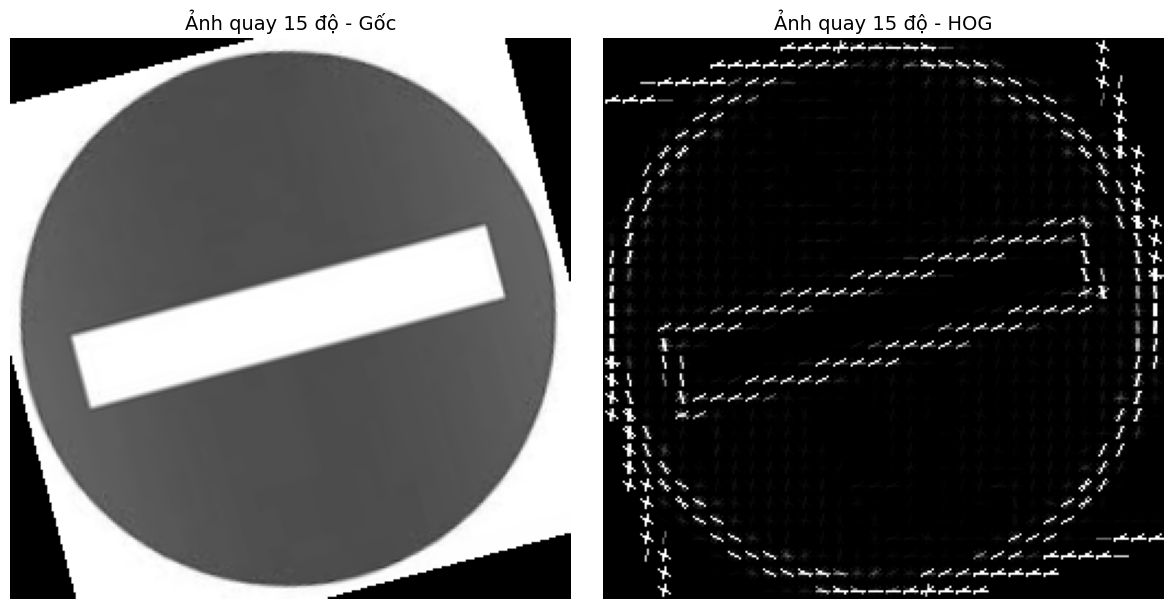

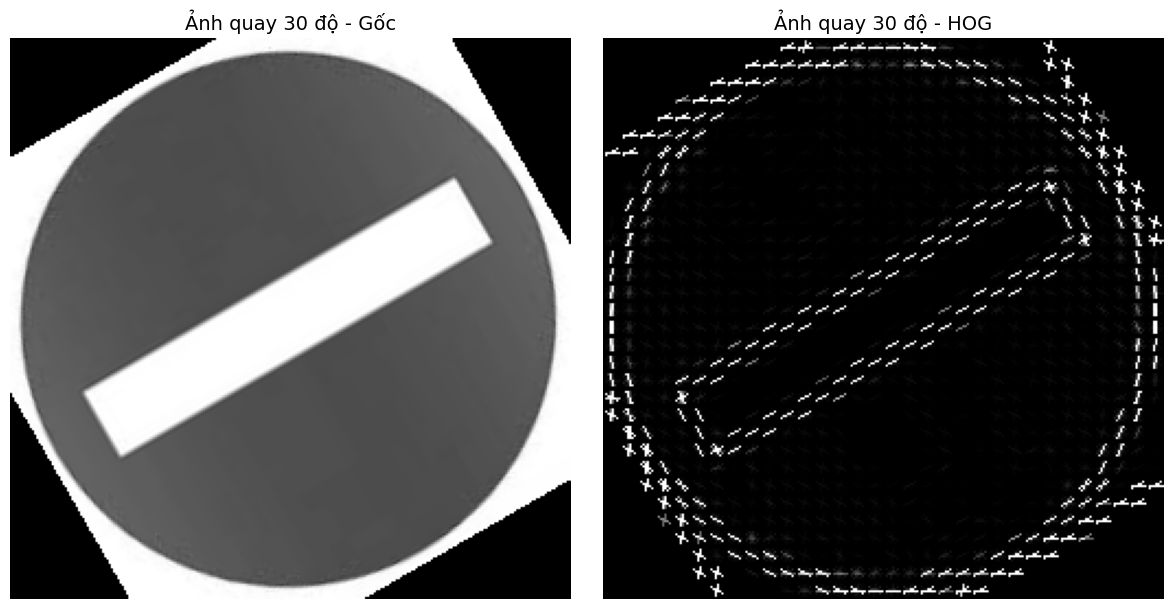

In [5]:
def get_rotated_image(img, angle):
    # Quay ảnh giữ nguyên kích thước khung nhìn, fill nền đen
    return rotate(img, angle, reshape=False)

# Quay xoay 15 độ
img_rot15 = get_rotated_image(img_original, 15)
_ = extract_and_visualize_hog(img_rot15, "Ảnh quay 15 độ")

# Quay xoay 30 độ
img_rot30 = get_rotated_image(img_original, 30)
_ = extract_and_visualize_hog(img_rot30, "Ảnh quay 30 độ")

**Nhận xét (Tính nhạy quay của HOG):**
- HOG lấy thông tin từ phân bố hướng cục bộ (chia luồng gradient thành các bin cố định như 0°, 20°, 40°,...). 
- Khi **quay ảnh**, phương của các cạnh thực tế thay đổi, dẫn đến gradient sẽ dịch chuyển số lượng "bỏ phiếu" (vote) sang nhóm bin khác. Hơn nữa, ảnh bị xoay kéo theo vị trí pixel dời sang các phân vùng "cell" hay "block" khác.
- Do đặc trưng vector HOG cuối cùng là sự nối tiếp tĩnh (flatten) của tất cả Histogram tại các vị trí cell/block cố định, một đối tượng bị quay đi sẽ tạo ra một vector đặc trưng **rất khác** so với ban đầu trên cơ sở tọa độ.
- Dựa vào visualization, ta thấy rõ các đường kẻ đại diện cho góc hướng bị xiên lệch đi. Điều này chứng tỏ **HOG rất nhạy cảm với sự thay đổi về phép quay (rotation sensitive)**. Nó không có tính bất biến với phép quay (rotation invariance). Muốn nhận dạng đối tượng ở các góc nghiêng khác nhau bằng HOG, người ta thường phải augment dữ liệu bằng cách học thêm chính các mẫu đã được quay.

## Core Tasks tuần này: HOG từ bản chất đến ứng dụng
Phần dưới đây hoàn thiện đầy đủ 4 yêu cầu cốt lõi:
1. Cài đặt HOG thủ công bằng NumPy.
2. So sánh với thư viện scikit-image.
3. Ứng dụng phân loại và phát hiện đối tượng.
4. Tổng hợp nội dung báo cáo thực hành.

In [8]:
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from skimage.feature import hog
from skimage import exposure, data

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    auc,
 )
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

np.random.seed(42)
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["axes.titlesize"] = 13

## 1) Cài đặt HOG từng bước bằng NumPy (Manual Implementation)
Pipeline gồm: tiền xử lý, gradient Sobel, lượng tử hướng, histogram theo cell, chuẩn hóa block và trực quan hóa.

In [2]:
def read_gray_image_safe(path):
    """Đọc ảnh xám an toàn trên Windows (kể cả đường dẫn có dấu tiếng Việt)."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Không tìm thấy ảnh: {path}")
    buffer = np.fromfile(str(path), dtype=np.uint8)
    img = cv2.imdecode(buffer, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Không thể giải mã ảnh: {path}")
    return img


def preprocess_for_hog(img, size=(128, 128)):
    """Resize và scale ảnh về [0, 1] cho pipeline HOG."""
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    return img.astype(np.float32) / 255.0


def compute_gradients(img):
    """Tính Gx, Gy bằng Sobel và suy ra magnitude + orientation."""
    gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)
    magnitude = np.sqrt(gx ** 2 + gy ** 2)
    orientation = (np.rad2deg(np.arctan2(gy, gx)) + 180.0) % 180.0
    return gx, gy, magnitude, orientation


def build_cell_histograms(magnitude, orientation, cell_size=8, n_bins=9):
    """Lượng tử orientation và bỏ phiếu theo magnitude cho từng cell."""
    h, w = magnitude.shape
    h_crop = (h // cell_size) * cell_size
    w_crop = (w // cell_size) * cell_size

    magnitude = magnitude[:h_crop, :w_crop]
    orientation = orientation[:h_crop, :w_crop]

    n_cells_y = h_crop // cell_size
    n_cells_x = w_crop // cell_size
    hist = np.zeros((n_cells_y, n_cells_x, n_bins), dtype=np.float32)

    bin_width = 180.0 / n_bins

    for cy in range(n_cells_y):
        for cx in range(n_cells_x):
            y0, y1 = cy * cell_size, (cy + 1) * cell_size
            x0, x1 = cx * cell_size, (cx + 1) * cell_size

            cell_mag = magnitude[y0:y1, x0:x1].ravel()
            cell_ori = orientation[y0:y1, x0:x1].ravel()

            bin_pos = cell_ori / bin_width
            bin_low = np.floor(bin_pos).astype(np.int32) % n_bins
            bin_high = (bin_low + 1) % n_bins

            w_high = bin_pos - np.floor(bin_pos)
            w_low = 1.0 - w_high

            cell_hist = np.zeros(n_bins, dtype=np.float32)
            np.add.at(cell_hist, bin_low, cell_mag * w_low)
            np.add.at(cell_hist, bin_high, cell_mag * w_high)

            hist[cy, cx] = cell_hist

    return hist, h_crop, w_crop


def normalize_block(block_vec, eps=1e-6, method="L2-Hys"):
    """Chuẩn hóa vector block theo L1, L2 hoặc L2-Hys."""
    if method == "L1":
        return block_vec / (np.sum(np.abs(block_vec)) + eps)
    if method == "L2":
        return block_vec / np.sqrt(np.sum(block_vec ** 2) + eps ** 2)
    if method == "L2-Hys":
        v = block_vec / np.sqrt(np.sum(block_vec ** 2) + eps ** 2)
        v = np.clip(v, 0.0, 0.2)
        return v / np.sqrt(np.sum(v ** 2) + eps ** 2)
    raise ValueError(f"Unsupported normalization method: {method}")


def blocks_to_feature(cell_hist, block_size=2, block_norm="L2-Hys"):
    """Trượt block (2x2 cell) và nối các block vector thành feature cuối."""
    n_cells_y, n_cells_x, _ = cell_hist.shape
    n_blocks_y = n_cells_y - block_size + 1
    n_blocks_x = n_cells_x - block_size + 1

    if n_blocks_y <= 0 or n_blocks_x <= 0:
        return np.array([], dtype=np.float32)

    features = []
    for by in range(n_blocks_y):
        for bx in range(n_blocks_x):
            block = cell_hist[by:by + block_size, bx:bx + block_size, :]
            block_vec = block.ravel()
            block_vec = normalize_block(block_vec, method=block_norm)
            features.append(block_vec)

    return np.concatenate(features).astype(np.float32)


def render_hog_from_cells(cell_hist, cell_size=8):
    """Vẽ line-segments biểu diễn hướng gradient ưu thế trong từng cell."""
    n_cells_y, n_cells_x, n_bins = cell_hist.shape
    vis = np.zeros((n_cells_y * cell_size, n_cells_x * cell_size), dtype=np.float32)

    angles = (np.arange(n_bins) + 0.5) * (180.0 / n_bins)
    radius = max(1.0, (cell_size // 2) - 1)

    for cy in range(n_cells_y):
        for cx in range(n_cells_x):
            hist = cell_hist[cy, cx]
            if hist.max() > 0:
                hist_draw = hist / (hist.max() + 1e-8)
            else:
                hist_draw = hist

            center_x = cx * cell_size + cell_size // 2
            center_y = cy * cell_size + cell_size // 2

            for b, strength in enumerate(hist_draw):
                angle = np.deg2rad(angles[b])
                dx = radius * strength * np.cos(angle)
                dy = radius * strength * np.sin(angle)

                x1, y1 = int(center_x - dx), int(center_y - dy)
                x2, y2 = int(center_x + dx), int(center_y + dy)
                cv2.line(vis, (x1, y1), (x2, y2), float(strength), 1, cv2.LINE_AA)

    return vis


def manual_hog(img, cell_size=8, block_size=2, n_bins=9, block_norm="L2-Hys"):
    gx, gy, magnitude, orientation = compute_gradients(img)
    cell_hist, h_crop, w_crop = build_cell_histograms(
        magnitude, orientation, cell_size=cell_size, n_bins=n_bins
    )
    feature_vec = blocks_to_feature(
        cell_hist, block_size=block_size, block_norm=block_norm
    )
    hog_vis = render_hog_from_cells(cell_hist, cell_size=cell_size)

    debug = {
        "gx": gx[:h_crop, :w_crop],
        "gy": gy[:h_crop, :w_crop],
        "magnitude": magnitude[:h_crop, :w_crop],
        "orientation": orientation[:h_crop, :w_crop],
        "cell_hist": cell_hist,
    }
    return feature_vec, hog_vis, debug

Đang dùng ảnh: data\cam-di-nguoc-chieu.jpeg
Manual HOG feature length: 8100


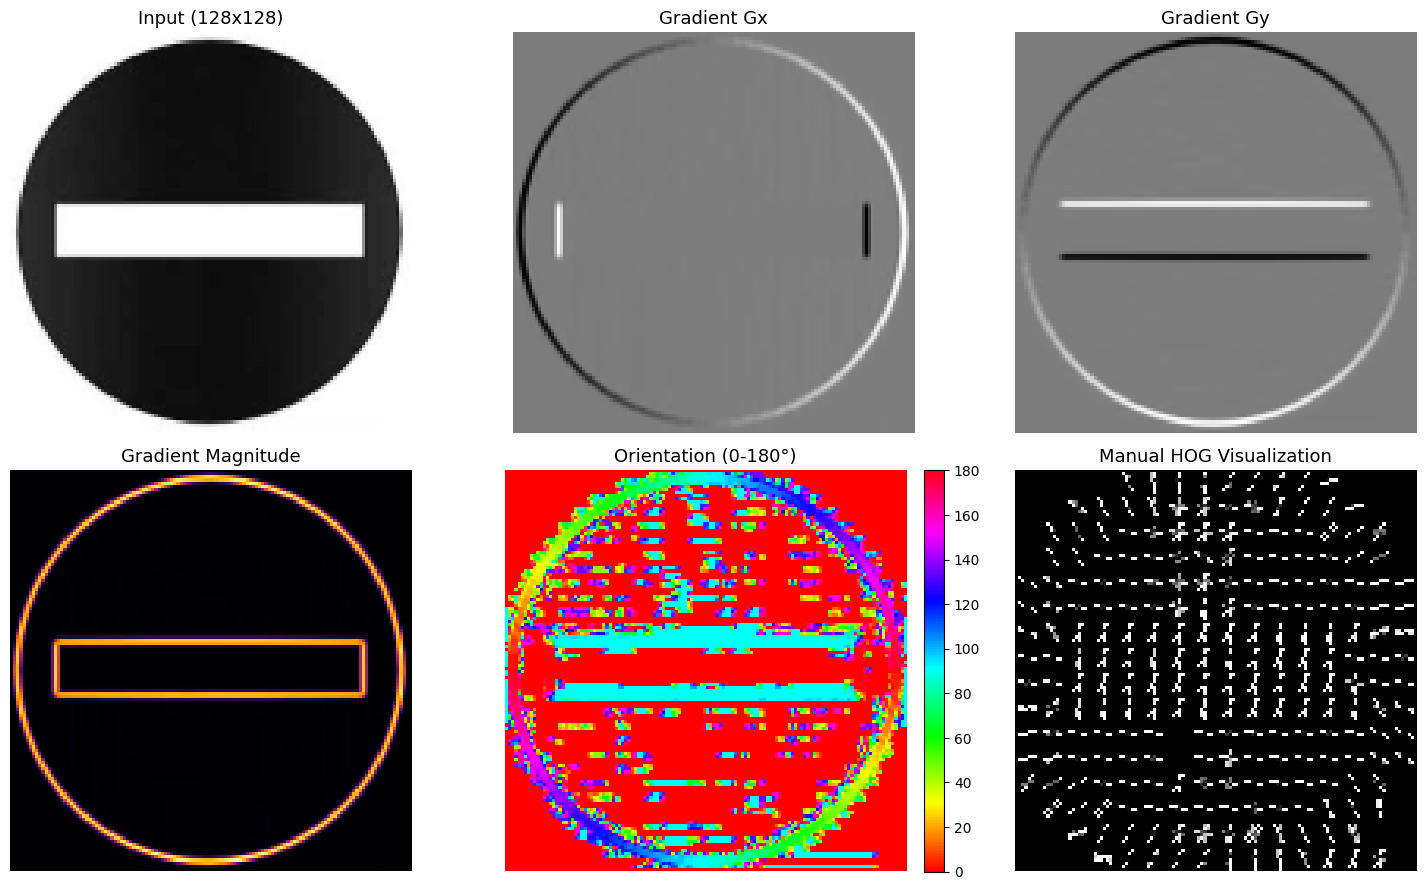

In [3]:
sample_candidates = [
    Path("data/cam-di-nguoc-chieu.jpeg"),
    Path("lab-10/data/cam-di-nguoc-chieu.jpeg"),
    Path("../lab-10/data/cam-di-nguoc-chieu.jpeg"),
]

img_raw = None
for p in sample_candidates:
    if p.exists():
        img_raw = read_gray_image_safe(p)
        print(f"Đang dùng ảnh: {p}")
        break

if img_raw is None:
    print("Không tìm thấy ảnh biển báo trong thư mục data, dùng ảnh camera mặc định.")
    img_raw = data.camera()

img_128 = preprocess_for_hog(img_raw, size=(128, 128))
feat_manual, vis_manual, debug_manual = manual_hog(
    img_128, cell_size=8, block_size=2, n_bins=9, block_norm="L2-Hys"
 )

print(f"Manual HOG feature length: {len(feat_manual)}")

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes[0, 0].imshow(img_128, cmap="gray")
axes[0, 0].set_title("Input (128x128)")
axes[0, 0].axis("off")

axes[0, 1].imshow(debug_manual["gx"], cmap="gray")
axes[0, 1].set_title("Gradient Gx")
axes[0, 1].axis("off")

axes[0, 2].imshow(debug_manual["gy"], cmap="gray")
axes[0, 2].set_title("Gradient Gy")
axes[0, 2].axis("off")

axes[1, 0].imshow(debug_manual["magnitude"], cmap="inferno")
axes[1, 0].set_title("Gradient Magnitude")
axes[1, 0].axis("off")

im = axes[1, 1].imshow(debug_manual["orientation"], cmap="hsv", vmin=0, vmax=180)
axes[1, 1].set_title("Orientation (0-180°)")
axes[1, 1].axis("off")
plt.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)

axes[1, 2].imshow(vis_manual, cmap="gray")
axes[1, 2].set_title("Manual HOG Visualization")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

## 2) Sử dụng thư viện và so sánh
So sánh manual HOG với scikit-image HOG theo 3 tiêu chí: chiều dài vector, thời gian chạy và độ chính xác khi phân loại.

Chiều dài vector manual: 8100
Chiều dài vector skimage: 8100
Thời gian trích đặc trưng 1 ảnh (manual):  10.80 ms
Thời gian trích đặc trưng 1 ảnh (skimage): 4.19 ms


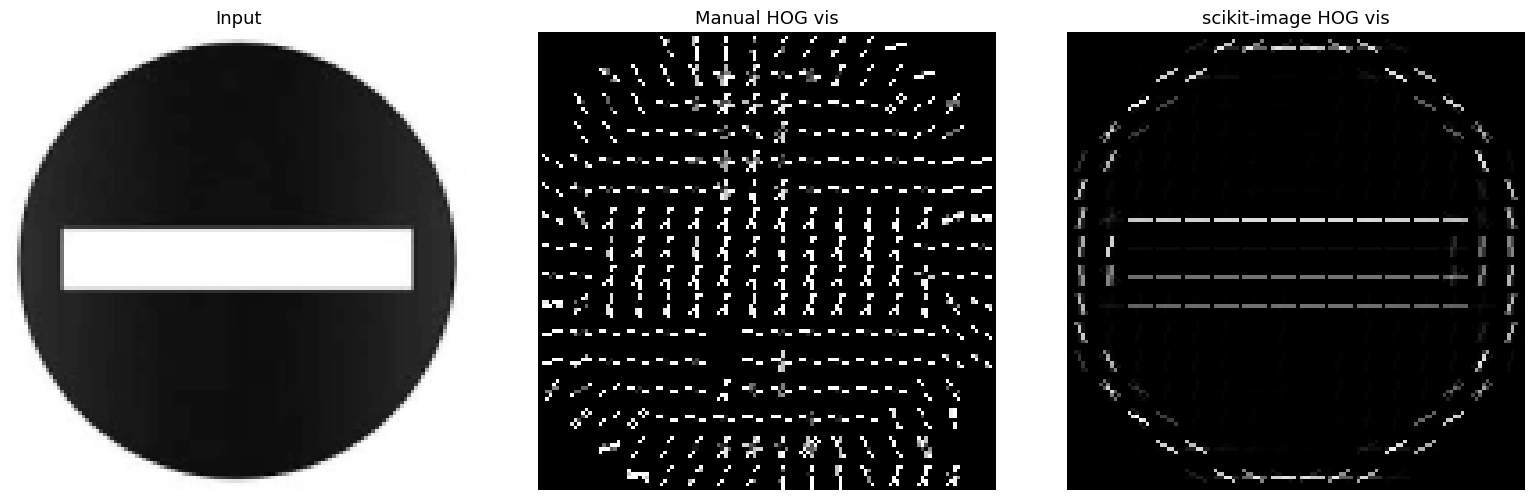

In [9]:
def skimage_hog_feature(
    img,
    cell_size=8,
    block_size=2,
    n_bins=9,
    block_norm="L2-Hys",
    visualize=False,
 ):
    if visualize:
        feat, hog_img = hog(
            img,
            orientations=n_bins,
            pixels_per_cell=(cell_size, cell_size),
            cells_per_block=(block_size, block_size),
            block_norm=block_norm,
            visualize=True,
            feature_vector=True,
        )
        hog_img = exposure.rescale_intensity(hog_img, in_range=(0, 10))
        return feat.astype(np.float32), hog_img
    feat = hog(
        img,
        orientations=n_bins,
        pixels_per_cell=(cell_size, cell_size),
        cells_per_block=(block_size, block_size),
        block_norm=block_norm,
        visualize=False,
        feature_vector=True,
    )
    return feat.astype(np.float32)


hog_cfg = {
    "cell_size": 8,
    "block_size": 2,
    "n_bins": 9,
    "block_norm": "L2-Hys",
}

# So sánh công bằng tốc độ trích đặc trưng (không tính visualization)
t0 = time.perf_counter()
gx, gy, mag, ori = compute_gradients(img_128)
cell_hist, _, _ = build_cell_histograms(
    mag, ori, cell_size=hog_cfg["cell_size"], n_bins=hog_cfg["n_bins"]
)
feat_manual_extract = blocks_to_feature(
    cell_hist, block_size=hog_cfg["block_size"], block_norm=hog_cfg["block_norm"]
)
t_manual_extract = time.perf_counter() - t0

t0 = time.perf_counter()
feat_lib_extract = skimage_hog_feature(img_128, visualize=False, **hog_cfg)
t_lib_extract = time.perf_counter() - t0

# Visualization để so sánh trực quan
feat_manual_vis, vis_manual_1, _ = manual_hog(img_128, **hog_cfg)
feat_lib_vis, vis_lib_1 = skimage_hog_feature(img_128, visualize=True, **hog_cfg)

print(f"Chiều dài vector manual: {len(feat_manual_extract)}")
print(f"Chiều dài vector skimage: {len(feat_lib_extract)}")
print(f"Thời gian trích đặc trưng 1 ảnh (manual):  {t_manual_extract*1000:.2f} ms")
print(f"Thời gian trích đặc trưng 1 ảnh (skimage): {t_lib_extract*1000:.2f} ms")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(img_128, cmap="gray")
axes[0].set_title("Input")
axes[0].axis("off")

axes[1].imshow(vis_manual_1, cmap="gray")
axes[1].set_title("Manual HOG vis")
axes[1].axis("off")

axes[2].imshow(vis_lib_1, cmap="gray")
axes[2].set_title("scikit-image HOG vis")
axes[2].axis("off")

plt.tight_layout()
plt.show()

Manual HOG:  0.790 ms/ảnh
Skimage HOG: 0.190 ms/ảnh


,feature,classifier,accuracy,train_time_sec,feature_dim
0,manual,LogisticRegression,0.988889,0.556836,324
1,skimage,LogisticRegression,0.988889,0.257870,324
2,manual,LinearSVC,0.982222,4.022260,324
3,skimage,LinearSVC,0.975556,2.958143,324


Best model: manual + LogisticRegression | accuracy = 0.9889


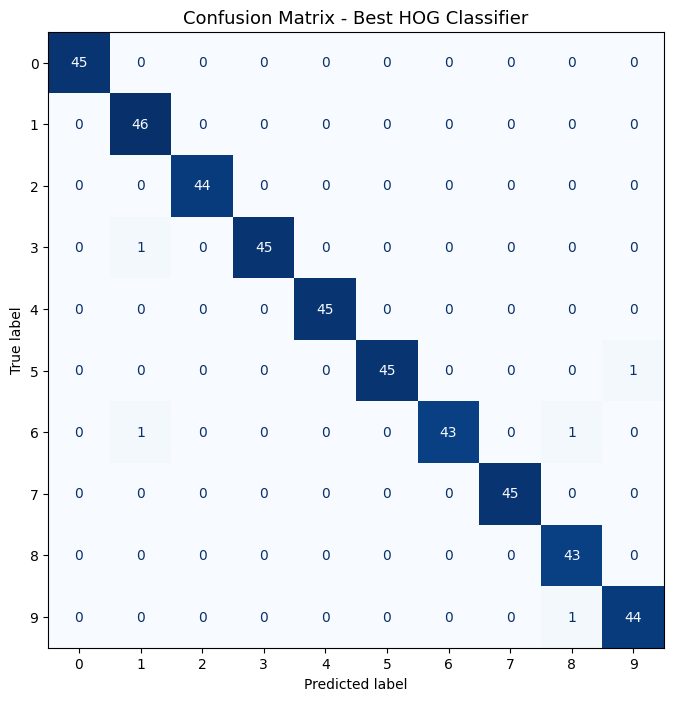

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        45
           1     0.9583    1.0000    0.9787        46
           2     1.0000    1.0000    1.0000        44
           3     1.0000    0.9783    0.9890        46
           4     1.0000    1.0000    1.0000        45
           5     1.0000    0.9783    0.9890        46
           6     1.0000    0.9556    0.9773        45
           7     1.0000    1.0000    1.0000        45
           8     0.9556    1.0000    0.9773        43
           9     0.9778    0.9778    0.9778        45

    accuracy                         0.9889       450
   macro avg     0.9892    0.9890    0.9889       450
weighted avg     0.9893    0.9889    0.9889       450



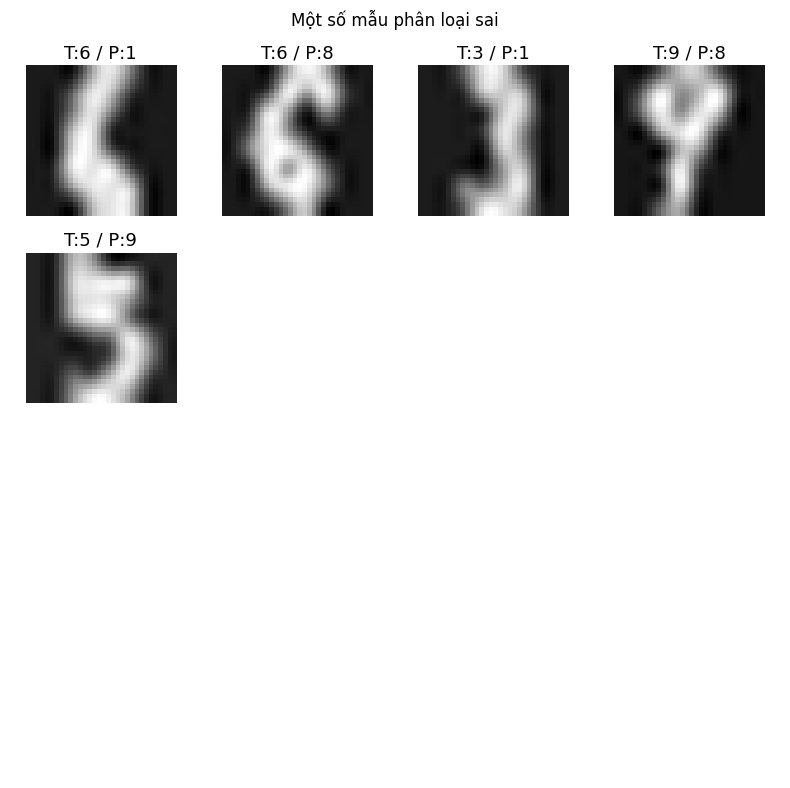

In [5]:
def extract_manual_batch(images, hog_cfg):
    feats = []
    t0 = time.perf_counter()
    for img in images:
        f, _, _ = manual_hog(img, **hog_cfg)
        feats.append(f)
    elapsed = time.perf_counter() - t0
    return np.asarray(feats, dtype=np.float32), elapsed


def extract_skimage_batch(images, hog_cfg):
    feats = []
    t0 = time.perf_counter()
    for img in images:
        f = skimage_hog_feature(img, visualize=False, **hog_cfg)
        feats.append(f)
    elapsed = time.perf_counter() - t0
    return np.asarray(feats, dtype=np.float32), elapsed


digits = load_digits()
X_digits = digits.images.astype(np.float32) / 16.0
y_digits = digits.target.astype(np.int32)

# Up-scale lên 32x32 để HOG có đủ cell/block
X_digits_32 = np.stack(
    [cv2.resize(img, (32, 32), interpolation=cv2.INTER_CUBIC) for img in X_digits],
    axis=0,
).astype(np.float32)

idx = np.arange(len(X_digits_32))
train_idx, test_idx = train_test_split(
    idx, test_size=0.25, random_state=42, stratify=y_digits
 )

X_train_img = X_digits_32[train_idx]
X_test_img = X_digits_32[test_idx]
y_train = y_digits[train_idx]
y_test = y_digits[test_idx]

# Benchmark thời gian trích HOG trên tập con để chạy nhanh
timing_subset = X_digits_32[:500]
_, t_manual = extract_manual_batch(timing_subset, hog_cfg)
_, t_skimage = extract_skimage_batch(timing_subset, hog_cfg)

print(f"Manual HOG:  {t_manual/len(timing_subset)*1000:.3f} ms/ảnh")
print(f"Skimage HOG: {t_skimage/len(timing_subset)*1000:.3f} ms/ảnh")

# Trích đặc trưng cho classification
X_train_manual, _ = extract_manual_batch(X_train_img, hog_cfg)
X_test_manual, _ = extract_manual_batch(X_test_img, hog_cfg)
X_train_sk, _ = extract_skimage_batch(X_train_img, hog_cfg)
X_test_sk, _ = extract_skimage_batch(X_test_img, hog_cfg)

feature_sets = {
    "manual": (X_train_manual, X_test_manual),
    "skimage": (X_train_sk, X_test_sk),
}

classifiers = {
    "LinearSVC": LinearSVC(dual=False, C=1.0, random_state=42, max_iter=5000),
    "LogisticRegression": LogisticRegression(
        max_iter=4000, solver="lbfgs", random_state=42
    ),
}

results = []
best_result = None

for feat_name, (Xtr, Xte) in feature_sets.items():
    for clf_name, clf in classifiers.items():
        model = make_pipeline(StandardScaler(), clf)
        t0 = time.perf_counter()
        model.fit(Xtr, y_train)
        train_time = time.perf_counter() - t0

        pred = model.predict(Xte)
        acc = accuracy_score(y_test, pred)

        row = {
            "feature": feat_name,
            "classifier": clf_name,
            "accuracy": acc,
            "train_time_sec": train_time,
            "feature_dim": Xtr.shape[1],
            "model": model,
            "pred": pred,
        }
        results.append(row)

        if best_result is None or acc > best_result["accuracy"]:
            best_result = row

results_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ["model", "pred"]} for r in results])
results_df = results_df.sort_values("accuracy", ascending=False).reset_index(drop=True)
display(results_df)

print(
    f"Best model: {best_result['feature']} + {best_result['classifier']} | "
    f"accuracy = {best_result['accuracy']:.4f}"
)

best_pred = best_result["pred"]
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_test, best_pred), display_labels=np.arange(10)
 )
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Confusion Matrix - Best HOG Classifier")
plt.show()

print(classification_report(y_test, best_pred, digits=4))

# Trực quan một số lỗi dự đoán
mis_idx = np.where(best_pred != y_test)[0][:16]
if len(mis_idx) > 0:
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for ax, i in zip(axes.ravel(), mis_idx):
        ax.imshow(X_test_img[i], cmap="gray")
        ax.set_title(f"T:{y_test[i]} / P:{best_pred[i]}")
        ax.axis("off")
    for ax in axes.ravel()[len(mis_idx):]:
        ax.axis("off")
    plt.suptitle("Một số mẫu phân loại sai")
    plt.tight_layout()
    plt.show()

## 3) Ứng dụng: Object Detector cổ điển với HOG
Triển khai detector cho lớp mục tiêu (digit 0) bằng image pyramid, sliding window và non-maximum suppression (NMS).

In [6]:
def image_pyramid(image, scale=1.25, min_size=(32, 32)):
    current = image.copy()
    level = 0
    while current.shape[0] >= min_size[1] and current.shape[1] >= min_size[0]:
        yield level, current
        level += 1
        new_w = int(current.shape[1] / scale)
        new_h = int(current.shape[0] / scale)
        if new_w < min_size[0] or new_h < min_size[1]:
            break
        current = cv2.resize(current, (new_w, new_h), interpolation=cv2.INTER_AREA)


def sliding_window(image, step=8, window_size=(32, 32)):
    win_w, win_h = window_size
    for y in range(0, image.shape[0] - win_h + 1, step):
        for x in range(0, image.shape[1] - win_w + 1, step):
            yield x, y, image[y:y + win_h, x:x + win_w]


def iou(box_a, box_b):
    xa1, ya1, xa2, ya2 = box_a
    xb1, yb1, xb2, yb2 = box_b

    inter_x1 = max(xa1, xb1)
    inter_y1 = max(ya1, yb1)
    inter_x2 = min(xa2, xb2)
    inter_y2 = min(ya2, yb2)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0, xa2 - xa1) * max(0, ya2 - ya1)
    area_b = max(0, xb2 - xb1) * max(0, yb2 - yb1)
    union_area = area_a + area_b - inter_area + 1e-9

    return inter_area / union_area


def non_max_suppression(boxes, scores, iou_threshold=0.3):
    if len(boxes) == 0:
        return [], []

    boxes = np.asarray(boxes, dtype=np.float32)
    scores = np.asarray(scores, dtype=np.float32)
    order = np.argsort(scores)[::-1]
    keep = []

    while order.size > 0:
        i = order[0]
        keep.append(i)
        if order.size == 1:
            break

        rest = order[1:]
        ious = np.array([iou(boxes[i], boxes[j]) for j in rest], dtype=np.float32)
        order = rest[ious < iou_threshold]

    kept_boxes = [tuple(map(int, b)) for b in boxes[keep]]
    kept_scores = [float(scores[i]) for i in keep]
    return kept_boxes, kept_scores


def detect_multiscale(
    image, detector, hog_cfg, window_size=(32, 32), step=8, scale=1.25, score_threshold=0.3
 ):
    raw_boxes = []
    raw_scores = []

    for level, scaled_img in image_pyramid(image, scale=scale, min_size=window_size):
        upscale = scale ** level
        for x, y, window in sliding_window(scaled_img, step=step, window_size=window_size):
            feat = skimage_hog_feature(window, visualize=False, **hog_cfg)
            score = float(detector.decision_function([feat])[0])
            if score >= score_threshold:
                x1 = int(x * upscale)
                y1 = int(y * upscale)
                x2 = int((x + window_size[0]) * upscale)
                y2 = int((y + window_size[1]) * upscale)
                x2 = min(x2, image.shape[1] - 1)
                y2 = min(y2, image.shape[0] - 1)
                raw_boxes.append((x1, y1, x2, y2))
                raw_scores.append(score)

    return raw_boxes, raw_scores


def build_synthetic_digit_scene(
    images, labels, canvas_size=(256, 256), n_objects=18, target_digit=0, seed=42
 ):
    rng = np.random.default_rng(seed)
    canvas = np.zeros(canvas_size, dtype=np.float32)
    gt_boxes = []

    idx_target = np.where(labels == target_digit)[0]
    idx_other = np.where(labels != target_digit)[0]

    n_target = max(3, n_objects // 4)
    n_other = n_objects - n_target

    chosen = np.concatenate(
        [
            rng.choice(idx_target, size=n_target, replace=True),
            rng.choice(idx_other, size=n_other, replace=True),
        ]
    )
    rng.shuffle(chosen)

    for idx_one in chosen:
        patch = images[idx_one]
        scale = float(rng.uniform(0.8, 1.6))
        size = int(32 * scale)
        size = max(24, min(56, size))

        patch = cv2.resize(patch, (size, size), interpolation=cv2.INTER_CUBIC)
        patch = np.clip(patch + rng.normal(0, 0.02, patch.shape), 0, 1)

        placed = False
        for _ in range(100):
            x = int(rng.integers(0, canvas_size[1] - size))
            y = int(rng.integers(0, canvas_size[0] - size))
            region = canvas[y:y + size, x:x + size]
            if region.mean() < 0.35:
                canvas[y:y + size, x:x + size] = np.maximum(region, patch)
                if labels[idx_one] == target_digit:
                    gt_boxes.append((x, y, x + size, y + size))
                placed = True
                break

        if not placed:
            x, y = 0, 0
            canvas[y:y + size, x:x + size] = np.maximum(
                canvas[y:y + size, x:x + size], patch
            )
            if labels[idx_one] == target_digit:
                gt_boxes.append((x, y, x + size, y + size))

    canvas = cv2.GaussianBlur(canvas, (3, 3), 0)
    return canvas, gt_boxes


def evaluate_detection(pred_boxes, gt_boxes, iou_threshold=0.3):
    matched_gt = set()
    tp = 0

    for pb in pred_boxes:
        best_iou = 0.0
        best_j = -1
        for j, gb in enumerate(gt_boxes):
            if j in matched_gt:
                continue
            cur_iou = iou(pb, gb)
            if cur_iou > best_iou:
                best_iou = cur_iou
                best_j = j

        if best_iou >= iou_threshold:
            tp += 1
            matched_gt.add(best_j)

    fp = len(pred_boxes) - tp
    fn = len(gt_boxes) - tp
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def draw_boxes(ax, image, boxes, color="lime", title=""):
    ax.imshow(image, cmap="gray")
    for (x1, y1, x2, y2) in boxes:
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1, linewidth=1.5, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
    ax.set_title(title)
    ax.axis("off")

[Detector training quality]
Accuracy:  0.9900
Precision: 0.9706
Recall:    1.0000
F1-score:  0.9851
PR-AUC:    0.9991

[Detection on synthetic scene]
Số ground-truth boxes (digit 0): 5
Số raw detections: 65
Số detections sau NMS: 25
TP=5, FP=20, FN=0 | Precision=0.200, Recall=1.000, F1=0.333


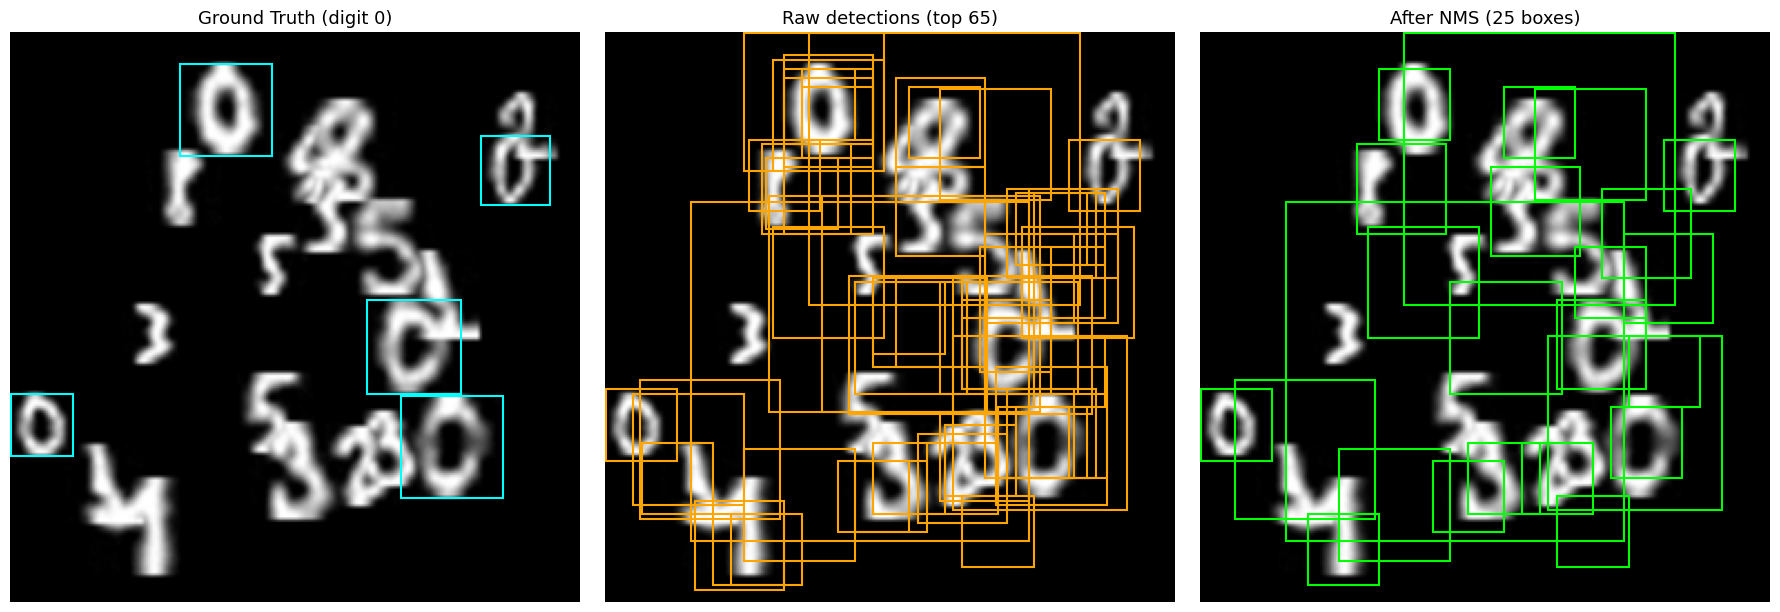

In [7]:
target_digit = 0

# Huấn luyện detector nhị phân: digit 0 (positive) vs not-0 (negative)
pos_imgs = X_train_img[y_train == target_digit]
neg_imgs = X_train_img[y_train != target_digit]

rng = np.random.default_rng(42)
n_pos = min(220, len(pos_imgs))
n_neg = min(2 * n_pos, len(neg_imgs))

pos_sel = pos_imgs[rng.choice(len(pos_imgs), size=n_pos, replace=False)]
neg_sel = neg_imgs[rng.choice(len(neg_imgs), size=n_neg, replace=False)]

X_pos, _ = extract_skimage_batch(pos_sel, hog_cfg)
X_neg, _ = extract_skimage_batch(neg_sel, hog_cfg)
y_pos = np.ones(len(X_pos), dtype=np.int32)
y_neg = np.zeros(len(X_neg), dtype=np.int32)

X_det = np.vstack([X_pos, X_neg])
y_det = np.hstack([y_pos, y_neg])

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_det, y_det, test_size=0.25, random_state=42, stratify=y_det
 )

detector = make_pipeline(
    StandardScaler(),
    LinearSVC(C=0.5, class_weight="balanced", random_state=42, max_iter=6000),
)
detector.fit(Xd_train, yd_train)

yd_pred = detector.predict(Xd_test)
det_clf_acc = accuracy_score(yd_test, yd_pred)
det_clf_prec = precision_score(yd_test, yd_pred)
det_clf_rec = recall_score(yd_test, yd_pred)
det_clf_f1 = f1_score(yd_test, yd_pred)

# PR-AUC cho detector nhị phân
yd_score = detector.decision_function(Xd_test)
prec_curve, rec_curve, _ = precision_recall_curve(yd_test, yd_score)
det_pr_auc = auc(rec_curve, prec_curve)

print("[Detector training quality]")
print(f"Accuracy:  {det_clf_acc:.4f}")
print(f"Precision: {det_clf_prec:.4f}")
print(f"Recall:    {det_clf_rec:.4f}")
print(f"F1-score:  {det_clf_f1:.4f}")
print(f"PR-AUC:    {det_pr_auc:.4f}")

# Tạo ảnh scene tổng hợp để chạy detector
scene, gt_boxes = build_synthetic_digit_scene(
    X_test_img, y_test, canvas_size=(256, 256), n_objects=20, target_digit=target_digit, seed=7
)

raw_boxes, raw_scores = detect_multiscale(
    scene,
    detector,
    hog_cfg,
    window_size=(32, 32),
    step=8,
    scale=1.25,
    score_threshold=0.35,
)

nms_boxes, nms_scores = non_max_suppression(raw_boxes, raw_scores, iou_threshold=0.25)
det_metrics = evaluate_detection(nms_boxes, gt_boxes, iou_threshold=0.3)

print("\n[Detection on synthetic scene]")
print(f"Số ground-truth boxes (digit {target_digit}): {len(gt_boxes)}")
print(f"Số raw detections: {len(raw_boxes)}")
print(f"Số detections sau NMS: {len(nms_boxes)}")
print(
    f"TP={det_metrics['tp']}, FP={det_metrics['fp']}, FN={det_metrics['fn']} | "
    f"Precision={det_metrics['precision']:.3f}, Recall={det_metrics['recall']:.3f}, F1={det_metrics['f1']:.3f}"
)

# Chỉ hiển thị top raw boxes theo score để hình đỡ rối
if len(raw_boxes) > 0:
    order = np.argsort(raw_scores)[::-1][:80]
    raw_boxes_vis = [raw_boxes[i] for i in order]
else:
    raw_boxes_vis = []

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
draw_boxes(
    axes[0], scene, gt_boxes, color="cyan", title=f"Ground Truth (digit {target_digit})"
 )
draw_boxes(
    axes[1], scene, raw_boxes_vis, color="orange", title=f"Raw detections (top {len(raw_boxes_vis)})"
 )
draw_boxes(
    axes[2], scene, nms_boxes, color="lime", title=f"After NMS ({len(nms_boxes)} boxes)"
 )
plt.tight_layout()
plt.show()

## 4) Khung báo cáo thực hành (điền trực tiếp từ kết quả chạy ở trên)

### 4.1 Mục tiêu và dữ liệu
- Mục tiêu: mô tả đầy đủ quy trình HOG và ứng dụng vào classification + detection.
- Dữ liệu thử nghiệm:
  - Ảnh biển báo/camera cho phần trực quan HOG.
  - Digits dataset cho phần đánh giá định lượng.

### 4.2 Cấu hình HOG
- Number of orientation bins: 9
- Cell size: 8x8
- Block size: 2x2
- Block normalization: L2-Hys

### 4.3 Kết quả định lượng và trực quan
- Ghi bảng so sánh manual vs scikit-image: feature length, ms/ảnh, accuracy.
- Chèn confusion matrix và các mẫu phân loại sai.
- Chèn ảnh detector: ground truth, raw boxes, sau NMS.

### 4.4 Phân tích lỗi (False Positive / False Negative)
- FP thường đến từ các vùng cạnh mạnh nhưng không mang hình dạng mục tiêu.
- FN thường do biến dạng hình học, contrast thấp, hoặc tỷ lệ object khác quá nhiều so với cửa sổ mẫu.
- HOG nhạy với rotation/scale nếu không augment hoặc không đủ tầng pyramid.

### 4.5 Kết luận
- Manual HOG giúp hiểu bản chất thuật toán.
- scikit-image HOG nhanh và ổn định hơn cho pipeline thực tế.
- Detector cổ điển HOG + LinearSVM vẫn hiệu quả với đối tượng đơn giản, nhưng cần tuning nhiều khi bối cảnh phức tạp.

## 5) Tuning detector để giảm False Positive
Mục tiêu: quét score threshold và IoU threshold của NMS trên nhiều scene tổng hợp để tìm cấu hình cân bằng Precision/Recall/F1 tốt hơn.

Top 10 cấu hình threshold cho detector:


,score_threshold,nms_iou_threshold,precision,recall,f1,tp,fp,fn,avg_pred_boxes_per_scene,avg_gt_boxes_per_scene
0,0.75,0.15,0.354839,0.88,0.505747,44,80,6,12.4,5.0
1,0.75,0.25,0.333333,0.92,0.489362,46,92,4,13.8,5.0
2,0.70,0.15,0.335821,0.90,0.489130,45,89,5,13.4,5.0
3,0.75,0.20,0.325926,0.88,0.475676,44,91,6,13.5,5.0
4,0.70,0.25,0.317568,0.94,0.474747,47,101,3,14.8,5.0
5,0.75,0.30,0.315068,0.92,0.469388,46,100,4,14.6,5.0
6,0.65,0.15,0.314685,0.90,0.466321,45,98,5,14.3,5.0
7,0.75,0.35,0.310811,0.92,0.464646,46,102,4,14.8,5.0
8,0.70,0.20,0.310345,0.90,0.461538,45,100,5,14.5,5.0
9,0.60,0.15,0.302632,0.92,0.455446,46,106,4,15.2,5.0


Best tuned thresholds -> score >= 0.75, NMS IoU = 0.15 | Precision=0.355, Recall=0.880, F1=0.506

[Baseline vs Tuned trên cùng scene]
Baseline (0.35, 0.25): TP=5, FP=15, FN=0, P=0.250, R=1.000, F1=0.400
Tuned    (0.75, 0.15): TP=5, FP=7, FN=0, P=0.417, R=1.000, F1=0.588


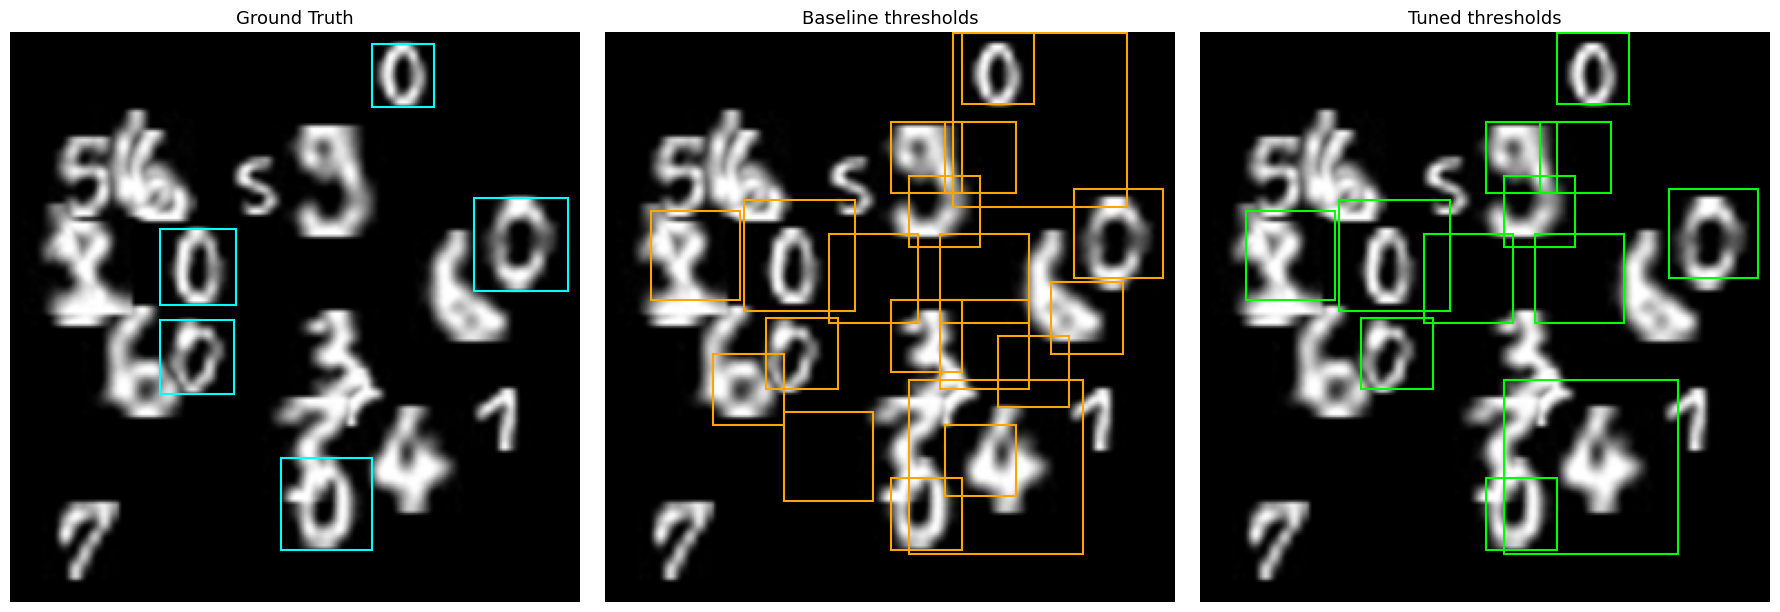

In [10]:
def apply_score_threshold_and_nms(raw_boxes, raw_scores, score_threshold=0.35, iou_threshold=0.25):
    idx = [i for i, s in enumerate(raw_scores) if s >= score_threshold]
    boxes = [raw_boxes[i] for i in idx]
    scores = [raw_scores[i] for i in idx]
    return non_max_suppression(boxes, scores, iou_threshold=iou_threshold)


def evaluate_grid_on_scene_cache(scene_cache, score_grid, iou_grid, iou_match=0.3):
    records = []
    for score_t in score_grid:
        for iou_t in iou_grid:
            total_tp, total_fp, total_fn = 0, 0, 0
            total_pred, total_gt = 0, 0

            for item in scene_cache:
                nms_boxes, _ = apply_score_threshold_and_nms(
                    item["raw_boxes"], item["raw_scores"], score_threshold=score_t, iou_threshold=iou_t
                )
                metrics = evaluate_detection(nms_boxes, item["gt_boxes"], iou_threshold=iou_match)
                total_tp += metrics["tp"]
                total_fp += metrics["fp"]
                total_fn += metrics["fn"]
                total_pred += len(nms_boxes)
                total_gt += len(item["gt_boxes"])

            precision = total_tp / (total_tp + total_fp + 1e-9)
            recall = total_tp / (total_tp + total_fn + 1e-9)
            f1 = 2 * precision * recall / (precision + recall + 1e-9)

            records.append(
                {
                    "score_threshold": score_t,
                    "nms_iou_threshold": iou_t,
                    "precision": precision,
                    "recall": recall,
                    "f1": f1,
                    "tp": total_tp,
                    "fp": total_fp,
                    "fn": total_fn,
                    "avg_pred_boxes_per_scene": total_pred / len(scene_cache),
                    "avg_gt_boxes_per_scene": total_gt / len(scene_cache),
                }
            )

    return pd.DataFrame(records)


def build_scene_cache(detector, hog_cfg, images, labels, target_digit=0, seeds=range(10)):
    cache = []
    for seed in seeds:
        scene_i, gt_i = build_synthetic_digit_scene(
            images,
            labels,
            canvas_size=(256, 256),
            n_objects=20,
            target_digit=target_digit,
            seed=int(seed),
        )
        raw_boxes_i, raw_scores_i = detect_multiscale(
            scene_i,
            detector,
            hog_cfg,
            window_size=(32, 32),
            step=8,
            scale=1.25,
            score_threshold=0.10,
        )
        cache.append(
            {
                "seed": int(seed),
                "scene": scene_i,
                "gt_boxes": gt_i,
                "raw_boxes": raw_boxes_i,
                "raw_scores": raw_scores_i,
            }
        )
    return cache


score_grid = [round(v, 2) for v in np.arange(0.25, 0.76, 0.05)]
iou_grid = [0.15, 0.20, 0.25, 0.30, 0.35]

scene_cache = build_scene_cache(
    detector,
    hog_cfg,
    X_test_img,
    y_test,
    target_digit=target_digit,
    seeds=range(10),
)

tuning_df = evaluate_grid_on_scene_cache(
    scene_cache,
    score_grid=score_grid,
    iou_grid=iou_grid,
    iou_match=0.30,
)
tuning_df = tuning_df.sort_values(["f1", "precision", "recall"], ascending=False).reset_index(drop=True)

print("Top 10 cấu hình threshold cho detector:")
display(tuning_df.head(10))

best_combo = tuning_df.iloc[0].to_dict()
best_score_thr = float(best_combo["score_threshold"])
best_nms_iou = float(best_combo["nms_iou_threshold"])

print(
    f"Best tuned thresholds -> score >= {best_score_thr:.2f}, NMS IoU = {best_nms_iou:.2f} | "
    f"Precision={best_combo['precision']:.3f}, Recall={best_combo['recall']:.3f}, F1={best_combo['f1']:.3f}"
)

# So sánh trực quan baseline vs tuned trên cùng một scene
scene_vis, gt_vis = build_synthetic_digit_scene(
    X_test_img, y_test, canvas_size=(256, 256), n_objects=20, target_digit=target_digit, seed=2026
)
raw_vis_boxes, raw_vis_scores = detect_multiscale(
    scene_vis,
    detector,
    hog_cfg,
    window_size=(32, 32),
    step=8,
    scale=1.25,
    score_threshold=0.10,
)

base_boxes, _ = apply_score_threshold_and_nms(
    raw_vis_boxes, raw_vis_scores, score_threshold=0.35, iou_threshold=0.25
)
tuned_boxes, _ = apply_score_threshold_and_nms(
    raw_vis_boxes, raw_vis_scores, score_threshold=best_score_thr, iou_threshold=best_nms_iou
)

base_metrics = evaluate_detection(base_boxes, gt_vis, iou_threshold=0.30)
tuned_metrics = evaluate_detection(tuned_boxes, gt_vis, iou_threshold=0.30)

print("\n[Baseline vs Tuned trên cùng scene]")
print(
    f"Baseline (0.35, 0.25): TP={base_metrics['tp']}, FP={base_metrics['fp']}, FN={base_metrics['fn']}, "
    f"P={base_metrics['precision']:.3f}, R={base_metrics['recall']:.3f}, F1={base_metrics['f1']:.3f}"
)
print(
    f"Tuned    ({best_score_thr:.2f}, {best_nms_iou:.2f}): TP={tuned_metrics['tp']}, FP={tuned_metrics['fp']}, FN={tuned_metrics['fn']}, "
    f"P={tuned_metrics['precision']:.3f}, R={tuned_metrics['recall']:.3f}, F1={tuned_metrics['f1']:.3f}"
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
draw_boxes(axes[0], scene_vis, gt_vis, color="cyan", title="Ground Truth")
draw_boxes(axes[1], scene_vis, base_boxes, color="orange", title="Baseline thresholds")
draw_boxes(axes[2], scene_vis, tuned_boxes, color="lime", title="Tuned thresholds")
plt.tight_layout()
plt.show()

## 6) Phân tích lỗi định lượng sâu hơn (Classification + Detection)
Phần này tạo bảng lỗi khó để giải thích rõ nguyên nhân False Positive / False Negative theo bản chất HOG.

[Classification] Per-class metrics (sắp theo F1 tăng dần):


,class,precision,recall,f1,support
0,6,1.000000,0.955556,0.977273,45
1,8,0.955556,1.000000,0.977273,43
2,9,0.977778,0.977778,0.977778,45
3,1,0.958333,1.000000,0.978723,46
4,5,1.000000,0.978261,0.989011,46
5,3,1.000000,0.978261,0.989011,46
6,2,1.000000,1.000000,1.000000,44
7,0,1.000000,1.000000,1.000000,45
8,7,1.000000,1.000000,1.000000,45
9,4,1.000000,1.000000,1.000000,45


[Classification] Top confusion pairs (True -> Pred):


,true,pred,count
0,3,1,1
1,5,9,1
2,6,1,1
3,6,8,1
4,9,8,1



[Detection] Scene-level error breakdown (after tuning):


,seed,tp,fp_near_miss,fp_background,fn,tp_iou_mean,fn_small,fn_medium,fn_large
0,0,3,0,7,2,0.632383,0,2,0
1,1,5,0,7,0,0.714047,0,0,0
2,2,5,0,8,0,0.649308,0,0,0
3,3,5,1,8,0,0.824404,0,0,0
4,4,4,0,10,1,0.683689,0,1,0
5,5,5,1,13,0,0.627405,0,0,0
6,6,4,1,7,1,0.658127,1,0,0
7,7,4,0,6,1,0.691437,1,0,0
8,8,5,2,3,0,0.661696,0,0,0
9,9,4,1,5,1,0.526478,1,0,0


[Detection] Tổng hợp lỗi sau tuning:


,metric,value
0,Total TP,44.0000
1,Total FP (near-miss),6.0000
2,Total FP (background),74.0000
3,Total FN,6.0000
4,Precision,0.3548
5,Recall,0.8800
6,F1,0.5057
7,Mean IoU on TP,0.6669
8,FN small,3.0000
9,FN medium,3.0000


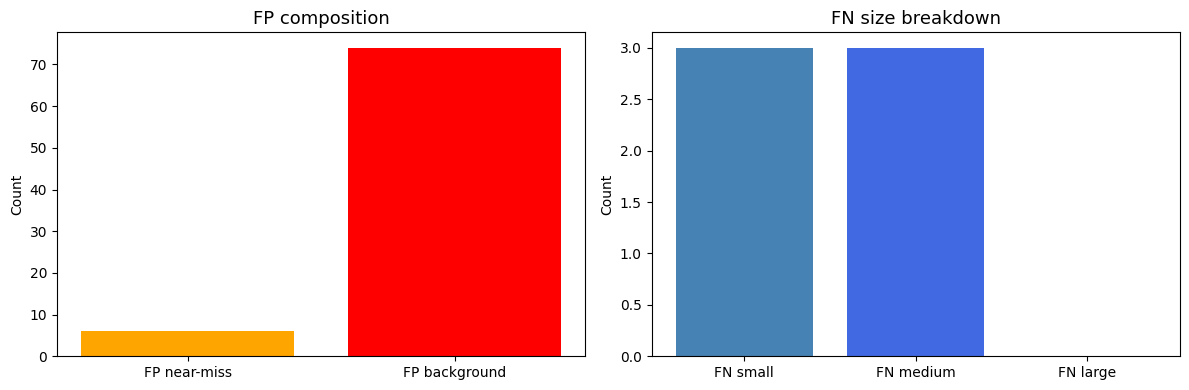

In [11]:
from sklearn.metrics import precision_recall_fscore_support


def build_top_confusion_pairs(y_true, y_pred, top_k=12):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(10))
    rows = []
    for t in range(cm.shape[0]):
        for p in range(cm.shape[1]):
            if t == p:
                continue
            if cm[t, p] > 0:
                rows.append({"true": t, "pred": p, "count": int(cm[t, p])})
    if not rows:
        return pd.DataFrame(columns=["true", "pred", "count"])
    return pd.DataFrame(rows).sort_values("count", ascending=False).head(top_k).reset_index(drop=True)


# 6.1 Classification error analysis
pr, rc, f1_cls, sup = precision_recall_fscore_support(
    y_test, best_pred, labels=np.arange(10), zero_division=0
)
class_error_df = pd.DataFrame(
    {
        "class": np.arange(10),
        "precision": pr,
        "recall": rc,
        "f1": f1_cls,
        "support": sup,
    }
).sort_values("f1").reset_index(drop=True)

top_confusions_df = build_top_confusion_pairs(y_test, best_pred, top_k=12)

print("[Classification] Per-class metrics (sắp theo F1 tăng dần):")
display(class_error_df)

print("[Classification] Top confusion pairs (True -> Pred):")
display(top_confusions_df)


# 6.2 Detection error analysis sau tuning
def detection_error_breakdown(pred_boxes, gt_boxes, iou_match=0.30):
    matched_gt = set()
    tp_ious = []
    fp_near_miss = 0
    fp_background = 0

    for pb in pred_boxes:
        ious = [iou(pb, gb) for gb in gt_boxes] if len(gt_boxes) > 0 else [0.0]
        best_iou = max(ious) if len(ious) > 0 else 0.0
        best_idx = int(np.argmax(ious)) if len(ious) > 0 else -1

        if best_iou >= iou_match and best_idx not in matched_gt:
            matched_gt.add(best_idx)
            tp_ious.append(best_iou)
        else:
            if best_iou >= 0.10:
                fp_near_miss += 1
            else:
                fp_background += 1

    fn_areas = []
    for j, gb in enumerate(gt_boxes):
        if j not in matched_gt:
            area = max(0, gb[2] - gb[0]) * max(0, gb[3] - gb[1])
            fn_areas.append(area)

    fn_small = sum(a < 32 * 32 for a in fn_areas)
    fn_medium = sum((a >= 32 * 32) and (a < 45 * 45) for a in fn_areas)
    fn_large = sum(a >= 45 * 45 for a in fn_areas)

    return {
        "tp": len(tp_ious),
        "fp_near_miss": fp_near_miss,
        "fp_background": fp_background,
        "fn": len(fn_areas),
        "tp_iou_mean": float(np.mean(tp_ious)) if len(tp_ious) > 0 else 0.0,
        "fn_small": int(fn_small),
        "fn_medium": int(fn_medium),
        "fn_large": int(fn_large),
    }


scene_level_rows = []
for item in scene_cache:
    tuned_boxes_i, _ = apply_score_threshold_and_nms(
        item["raw_boxes"], item["raw_scores"], score_threshold=best_score_thr, iou_threshold=best_nms_iou
    )
    breakdown = detection_error_breakdown(tuned_boxes_i, item["gt_boxes"], iou_match=0.30)
    scene_level_rows.append({"seed": item["seed"], **breakdown})

det_error_df = pd.DataFrame(scene_level_rows)

agg_det = det_error_df.drop(columns=["seed"]).sum(numeric_only=True).to_dict()
tp_total = agg_det.get("tp", 0)
fp_total = agg_det.get("fp_near_miss", 0) + agg_det.get("fp_background", 0)
fn_total = agg_det.get("fn", 0)
precision_total = tp_total / (tp_total + fp_total + 1e-9)
recall_total = tp_total / (tp_total + fn_total + 1e-9)
f1_total = 2 * precision_total * recall_total / (precision_total + recall_total + 1e-9)

print("\n[Detection] Scene-level error breakdown (after tuning):")
display(det_error_df)

summary_det_df = pd.DataFrame(
    [
        {"metric": "Total TP", "value": tp_total},
        {"metric": "Total FP (near-miss)", "value": agg_det.get("fp_near_miss", 0)},
        {"metric": "Total FP (background)", "value": agg_det.get("fp_background", 0)},
        {"metric": "Total FN", "value": fn_total},
        {"metric": "Precision", "value": round(float(precision_total), 4)},
        {"metric": "Recall", "value": round(float(recall_total), 4)},
        {"metric": "F1", "value": round(float(f1_total), 4)},
        {
            "metric": "Mean IoU on TP",
            "value": round(float(det_error_df["tp_iou_mean"].replace(0, np.nan).mean(skipna=True)), 4),
        },
        {"metric": "FN small", "value": int(agg_det.get("fn_small", 0))},
        {"metric": "FN medium", "value": int(agg_det.get("fn_medium", 0))},
        {"metric": "FN large", "value": int(agg_det.get("fn_large", 0))},
    ]
)

print("[Detection] Tổng hợp lỗi sau tuning:")
display(summary_det_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fp_bar = [agg_det.get("fp_near_miss", 0), agg_det.get("fp_background", 0)]
axes[0].bar(["FP near-miss", "FP background"], fp_bar, color=["orange", "red"])
axes[0].set_title("FP composition")
axes[0].set_ylabel("Count")

fn_bar = [agg_det.get("fn_small", 0), agg_det.get("fn_medium", 0), agg_det.get("fn_large", 0)]
axes[1].bar(["FN small", "FN medium", "FN large"], fn_bar, color=["steelblue", "royalblue", "navy"])
axes[1].set_title("FN size breakdown")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Gợi ý viết phần "Phân tích lỗi" trong báo cáo
- Classification: tập trung vào các cặp lớp dễ nhầm nhất trong bảng confusion pairs (ví dụ True->Pred có count cao).
- Detection: tách FP thành near-miss và background để chỉ ra lỗi do cửa sổ lệch vị trí hay do nhiễu nền.
- Nếu FN tập trung ở nhóm small object, cần giảm step của sliding window hoặc tăng số mức pyramid để bắt đối tượng nhỏ tốt hơn.

## 7) Export artifacts cho báo cáo
Cell này lưu bảng số liệu và hình minh họa ra thư mục outputs để chèn trực tiếp vào file LaTeX.

In [12]:
from pathlib import Path

out_dir = Path("outputs")
out_dir.mkdir(parents=True, exist_ok=True)

# 1) Export bảng số liệu
results_df.to_csv(out_dir / "classification_model_comparison.csv", index=False)
tuning_df.to_csv(out_dir / "detector_threshold_tuning.csv", index=False)
class_error_df.to_csv(out_dir / "classification_per_class_metrics.csv", index=False)
top_confusions_df.to_csv(out_dir / "classification_top_confusions.csv", index=False)
det_error_df.to_csv(out_dir / "detection_scene_level_breakdown.csv", index=False)
summary_det_df.to_csv(out_dir / "detection_summary_metrics.csv", index=False)

# 2) Export hình pipeline manual HOG
fig1, axes1 = plt.subplots(2, 3, figsize=(15, 9))
axes1[0, 0].imshow(img_128, cmap="gray")
axes1[0, 0].set_title("Input (128x128)")
axes1[0, 0].axis("off")

axes1[0, 1].imshow(debug_manual["gx"], cmap="gray")
axes1[0, 1].set_title("Gradient Gx")
axes1[0, 1].axis("off")

axes1[0, 2].imshow(debug_manual["gy"], cmap="gray")
axes1[0, 2].set_title("Gradient Gy")
axes1[0, 2].axis("off")

axes1[1, 0].imshow(debug_manual["magnitude"], cmap="inferno")
axes1[1, 0].set_title("Gradient Magnitude")
axes1[1, 0].axis("off")

im1 = axes1[1, 1].imshow(debug_manual["orientation"], cmap="hsv", vmin=0, vmax=180)
axes1[1, 1].set_title("Orientation (0-180°)")
axes1[1, 1].axis("off")
fig1.colorbar(im1, ax=axes1[1, 1], fraction=0.046, pad=0.04)

axes1[1, 2].imshow(vis_manual, cmap="gray")
axes1[1, 2].set_title("Manual HOG Visualization")
axes1[1, 2].axis("off")

fig1.tight_layout()
fig1.savefig(out_dir / "manual_hog_pipeline.png", dpi=180, bbox_inches="tight")
plt.close(fig1)

# 3) Export confusion matrix
fig2, ax2 = plt.subplots(figsize=(7, 7))
disp2 = ConfusionMatrixDisplay(confusion_matrix(y_test, best_pred), display_labels=np.arange(10))
disp2.plot(ax=ax2, cmap="Blues", values_format="d", colorbar=False)
ax2.set_title("Confusion Matrix - Best HOG Classifier")
fig2.tight_layout()
fig2.savefig(out_dir / "classification_confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.close(fig2)

# 4) Export baseline vs tuned detector visualization
fig3, axes3 = plt.subplots(1, 3, figsize=(18, 6))
draw_boxes(axes3[0], scene_vis, gt_vis, color="cyan", title="Ground Truth")
draw_boxes(axes3[1], scene_vis, base_boxes, color="orange", title="Baseline thresholds")
draw_boxes(axes3[2], scene_vis, tuned_boxes, color="lime", title="Tuned thresholds")
fig3.tight_layout()
fig3.savefig(out_dir / "detector_baseline_vs_tuned.png", dpi=180, bbox_inches="tight")
plt.close(fig3)

# 5) Export FP/FN error breakdown chart
fig4, axes4 = plt.subplots(1, 2, figsize=(12, 4))
fp_bar = [agg_det.get("fp_near_miss", 0), agg_det.get("fp_background", 0)]
axes4[0].bar(["FP near-miss", "FP background"], fp_bar, color=["orange", "red"])
axes4[0].set_title("FP composition")
axes4[0].set_ylabel("Count")

fn_bar = [agg_det.get("fn_small", 0), agg_det.get("fn_medium", 0), agg_det.get("fn_large", 0)]
axes4[1].bar(["FN small", "FN medium", "FN large"], fn_bar, color=["steelblue", "royalblue", "navy"])
axes4[1].set_title("FN size breakdown")
axes4[1].set_ylabel("Count")

fig4.tight_layout()
fig4.savefig(out_dir / "detector_error_breakdown.png", dpi=180, bbox_inches="tight")
plt.close(fig4)

print(f"Đã export artifacts vào: {out_dir.resolve()}")
print("- CSV:", len(list(out_dir.glob("*.csv"))), "file")
print("- PNG:", len(list(out_dir.glob("*.png"))), "file")

Đã export artifacts vào: B:\HUS\TaiLieuOnThi\2025-20262\Thị giác máy tính\computer-vision-mat3562\lab-10\outputs
- CSV: 6 file
- PNG: 4 file
